In [2]:
import numpy as np 
import pandas as pd
import seaborn as sns

In [3]:
df = sns.load_dataset("iris")   # small letters me likhna
print(df.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [4]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:

df = df.iloc[:,1:]

In [6]:
df.head()

,sepal_width,petal_length,petal_width,species
0,3.5,1.4,0.2,setosa
1,3.0,1.4,0.2,setosa
2,3.2,1.3,0.2,setosa
3,3.1,1.5,0.2,setosa
4,3.6,1.4,0.2,setosa


In [7]:
from sklearn.preprocessing import LabelEncoder

In [8]:
encoder = LabelEncoder()

In [9]:
df['species'] = encoder.fit_transform(df['species'])

In [10]:

df.head()

,sepal_width,petal_length,petal_width,species
0,3.5,1.4,0.2,0
1,3.0,1.4,0.2,0
2,3.2,1.3,0.2,0
3,3.1,1.5,0.2,0
4,3.6,1.4,0.2,0


In [15]:
df = df[df['species'] != 0][['sepal_width','petal_length','species']]

In [16]:
df.head()

,sepal_width,petal_length,species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [17]:

import seaborn as sns
import matplotlib.pyplot as plt

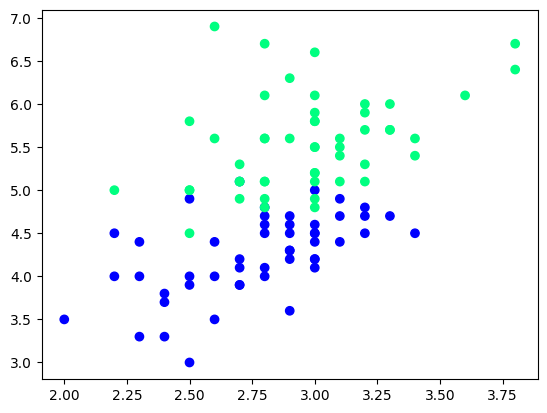

In [18]:
plt.scatter(df['sepal_width'],df['petal_length'],c=df['species'],cmap='winter')

In [19]:
df_train = df.iloc[:60,:].sample(10)
df_train


,sepal_width,petal_length,species
80,2.4,3.8,1
65,3.1,4.4,1
101,2.7,5.1,2
96,2.9,4.2,1
71,2.8,4.0,1
93,2.3,3.3,1
67,2.7,4.1,1
64,2.9,3.6,1
106,2.5,4.5,2
68,2.2,4.5,1


In [20]:

# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [22]:
df_train

,sepal_width,petal_length,species
107,2.9,6.3,2
96,2.9,4.2,1
52,3.1,4.9,1
145,3.0,5.2,2
108,2.5,5.8,2
86,3.1,4.7,1
149,3.0,5.1,2
136,3.4,5.6,2
112,3.0,5.5,2
103,2.9,5.6,2


In [23]:
df_val

,sepal_width,petal_length,species
76,2.8,4.8,1
71,2.8,4.0,1
130,2.8,6.1,2
53,2.3,4.0,1
54,2.8,4.6,1


In [24]:
df_test

,sepal_width,petal_length,species
127,3.0,4.9,2
88,3.0,4.1,1
69,2.5,3.9,1
73,2.8,4.7,1
77,3.0,5.0,1


In [26]:

X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [27]:

y_test

array([1, 1, 2, 1, 1])


Case 1 - Bagging

In [28]:

# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal_width,petal_length,species
86,3.1,4.7,1
108,2.5,5.8,2
149,3.0,5.1,2
145,3.0,5.2,2
145,3.0,5.2,2
108,2.5,5.8,2
96,2.9,4.2,1
86,3.1,4.7,1


In [35]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import r2_score, mean_squared_error

In [38]:
# 1. Model banao
dt_bag1 = DecisionTreeClassifier()

# 2. Train karo (MOST IMPORTANT)
dt_bag1.fit(X, y)

# 3. Evaluate karo
evaluate(dt_bag1, X, y)

R2 Score: 1.0
MSE: 0.0


In [39]:

evaluate(dt_bag1,X,y)

R2 Score: 1.0
MSE: 0.0


In [40]:

# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal_width,petal_length,species
96,2.9,4.2,1
112,3.0,5.5,2
86,3.1,4.7,1
112,3.0,5.5,2
86,3.1,4.7,1
112,3.0,5.5,2
145,3.0,5.2,2
96,2.9,4.2,1


In [42]:
# 1. Model banao
dt_bag2 = DecisionTreeClassifier()

# 2. Train karo (MOST IMPORTANT)
dt_bag2.fit(X, y)

# 3. Evaluate karo
evaluate(dt_bag2, X, y)

R2 Score: 1.0
MSE: 0.0


In [43]:

# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal_width,petal_length,species
103,2.9,5.6,2
52,3.1,4.9,1
103,2.9,5.6,2
52,3.1,4.9,1
108,2.5,5.8,2
112,3.0,5.5,2
96,2.9,4.2,1
149,3.0,5.1,2


In [44]:
# 1. Model banao
dt_bag3 = DecisionTreeClassifier()

# 2. Train karo (MOST IMPORTANT)
dt_bag3.fit(X, y)

# 3. Evaluate karo
evaluate(dt_bag3, X, y)

R2 Score: 1.0
MSE: 0.0


In [45]:

def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))
    


Predict

In [46]:
df_test

,sepal_width,petal_length,species
127,3.0,4.9,2
88,3.0,4.1,1
69,2.5,3.9,1
73,2.8,4.7,1
77,3.0,5.0,1


In [47]:

print("Predictor 1",dt_bag1.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.2,5.0]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [2]
Predictor 3 [1]


C:\Users\03-11-24\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\03-11-24\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\03-11-24\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(



Pasting

In [48]:

# Row sampling without replacement
df_train

,sepal_width,petal_length,species
107,2.9,6.3,2
96,2.9,4.2,1
52,3.1,4.9,1
145,3.0,5.2,2
108,2.5,5.8,2
86,3.1,4.7,1
149,3.0,5.1,2
136,3.4,5.6,2
112,3.0,5.5,2
103,2.9,5.6,2


In [49]:

df_train.sample(8)

,sepal_width,petal_length,species
107,2.9,6.3,2
136,3.4,5.6,2
103,2.9,5.6,2
149,3.0,5.1,2
108,2.5,5.8,2
96,2.9,4.2,1
86,3.1,4.7,1
145,3.0,5.2,2



Random Subspaces

In [51]:
df1 = sns.load_dataset("iris") 

In [52]:
df1 = df1.sample(10)

In [53]:
df1

,sepal_length,sepal_width,petal_length,petal_width,species
129,7.2,3.0,5.8,1.6,virginica
91,6.1,3.0,4.6,1.4,versicolor
15,5.7,4.4,1.5,0.4,setosa
76,6.8,2.8,4.8,1.4,versicolor
101,5.8,2.7,5.1,1.9,virginica
105,7.6,3.0,6.6,2.1,virginica
77,6.7,3.0,5.0,1.7,versicolor
80,5.5,2.4,3.8,1.1,versicolor
4,5.0,3.6,1.4,0.2,setosa
67,5.8,2.7,4.1,1.0,versicolor


In [54]:

df1.sample(2,replace=True,axis=1)

,species,species
129,virginica,virginica
91,versicolor,versicolor
15,setosa,setosa
76,versicolor,versicolor
101,virginica,virginica
105,virginica,virginica
77,versicolor,versicolor
80,versicolor,versicolor
4,setosa,setosa
67,versicolor,versicolor


In [55]:
df1

,sepal_length,sepal_width,petal_length,petal_width,species
129,7.2,3.0,5.8,1.6,virginica
91,6.1,3.0,4.6,1.4,versicolor
15,5.7,4.4,1.5,0.4,setosa
76,6.8,2.8,4.8,1.4,versicolor
101,5.8,2.7,5.1,1.9,virginica
105,7.6,3.0,6.6,2.1,virginica
77,6.7,3.0,5.0,1.7,versicolor
80,5.5,2.4,3.8,1.1,versicolor
4,5.0,3.6,1.4,0.2,setosa
67,5.8,2.7,4.1,1.0,versicolor


In [56]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,sepal_length,sepal_length
15,5.7,5.7
91,6.1,6.1
129,7.2,7.2
91,6.1,6.1
4,5.0,5.0
15,5.7,5.7
76,6.8,6.8
101,5.8,5.8
